<a href="https://www.kaggle.com/code/nerdyalgorithm/fork-of-predicting-fatigue-cross-check?scriptVersionId=282750577" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## this is a scattered crosscheck code file

In [2]:
import pandas as pd
import os

# 📂 Define the paths for the "Before" and "After" shots
# Based on the file list you showed me: Subject 01 has Session 01, 02, and 03.
path_alert    = '/kaggle/input/mental-fatigue-level-detection-fatigueset-data/fatigueset/01/01/forehead_eeg_raw.csv'
path_fatigued = '/kaggle/input/mental-fatigue-level-detection-fatigueset-data/fatigueset/01/03/forehead_eeg_raw.csv'

# 1. Load the "Before" (Alert) Data
if os.path.exists(path_alert):
    df_alert = pd.read_csv(path_alert)
    print(f"✅ Loaded Alert Data (Session 01). Shape: {df_alert.shape}")
else:
    print("❌ Error: Could not find Alert file.")

# 2. Load the "After" (Fatigued) Data
if os.path.exists(path_fatigued):
    df_fatigued = pd.read_csv(path_fatigued)
    print(f"✅ Loaded Fatigued Data (Session 03). Shape: {df_fatigued.shape}")
else:
    print("❌ Error: Could not find Fatigued file.")

# 3. Add a "Label" Column (Teaching the machine the answer)
# 0 = Alert, 1 = Fatigued
df_alert['label'] = 0
df_fatigued['label'] = 1

print("\n🚀 Logic Check: We now have labeled data ready for analysis.")

✅ Loaded Alert Data (Session 01). Shape: (369290, 5)
✅ Loaded Fatigued Data (Session 03). Shape: (324828, 5)

🚀 Logic Check: We now have labeled data ready for analysis.


🔵 Processing ALERT State (Session 01)...
Creating RawArray with float64 data, n_channels=4, n_times=369290
    Range : 0 ... 369289 =      0.000 ...  1442.535 secs
Ready.
📉 Generating Plot for: ALERT (Baseline)
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


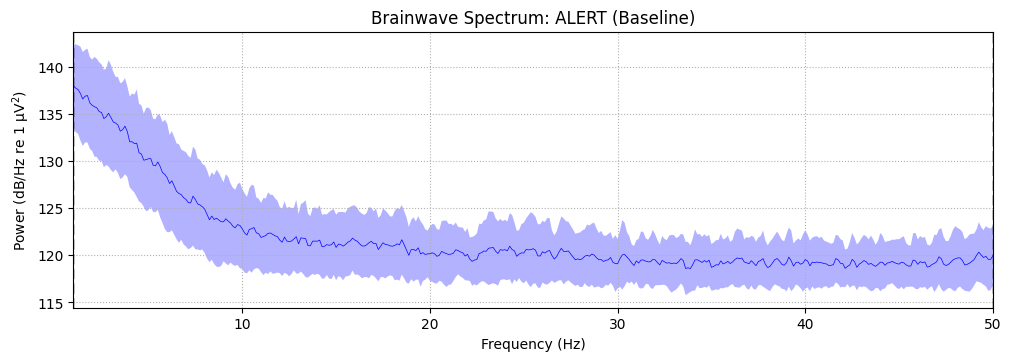


🔴 Processing FATIGUED State (Session 03)...
Creating RawArray with float64 data, n_channels=4, n_times=324828
    Range : 0 ... 324827 =      0.000 ...  1268.855 secs
Ready.
📉 Generating Plot for: FATIGUED (End of Task)
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


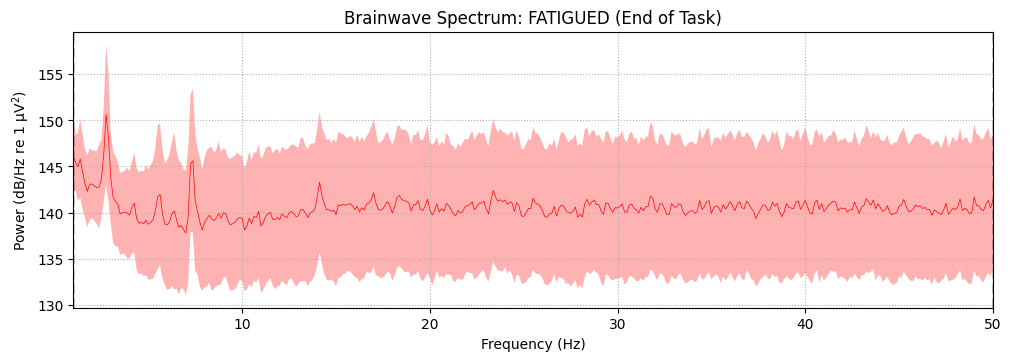

In [3]:
import mne
import matplotlib.pyplot as plt

def process_and_plot(df, title, color):
    """
    1. Converts DF to MNE Raw Object
    2. Applies Bandpass Filter (1-50Hz)
    3. Plots the Power Spectral Density (PSD)
    """
    # 1. Select only EEG columns
    eeg_cols = ['TP9', 'AF7', 'AF8', 'TP10']
    data = df[eeg_cols].values.T
    
    # 2. Create MNE Object
    info = mne.create_info(ch_names=eeg_cols, sfreq=256, ch_types='eeg')
    raw = mne.io.RawArray(data, info)
    
    # Set montage (Standard 10-20 System)
    # We wrap this in try-except in case of version differences, to prevent crashes
    try:
        raw.set_montage(mne.channels.make_standard_montage('standard_1020'))
    except:
        pass
    
    # 3. Apply Trejo Filter (1-50Hz)
    raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=50.0, verbose=False)
    
    # 4. Compute PSD
    print(f"📉 Generating Plot for: {title}")
    spectrum = raw_filtered.compute_psd(fmin=1, fmax=50)
    
    # 5. Plot (Fixed: We let MNE create the figure to avoid the crash)
    # average=True merges all 4 sensors into one clean line so it's easier to read
    fig = spectrum.plot(average=True, color=color, show=False)
    plt.title(f"Brainwave Spectrum: {title}")
    plt.show()
    
    return raw_filtered

# --- EXECUTE THE COMPARISON ---
print("🔵 Processing ALERT State (Session 01)...")
# We use 'blue' for alert
raw_alert = process_and_plot(df_alert, "ALERT (Baseline)", 'blue')

print("\n🔴 Processing FATIGUED State (Session 03)...")
# We use 'red' for fatigued
raw_fatigued = process_and_plot(df_fatigued, "FATIGUED (End of Task)", 'red')

In [4]:
import numpy as np

def create_epochs(raw_obj, label, window_sec=4, step_sec=2):
    """
    Slices the continuous EEG into 4-second overlapping windows.
    Returns: X (Features), y (Labels)
    """
    sfreq = 256 # Frequency
    window_samples = int(window_sec * sfreq)
    step_samples = int(step_sec * sfreq)
    
    # Get the raw data matrix (Channels x Time)
    data = raw_obj.get_data()
    n_channels, n_time = data.shape
    
    epochs = []
    labels = []
    
    # Slide the window across the data
    for start in range(0, n_time - window_samples, step_samples):
        end = start + window_samples
        epoch = data[:, start:end]
        
        # We append this "snapshot" to our list
        epochs.append(epoch)
        labels.append(label)
        
    return np.array(epochs), np.array(labels)

# --- EXECUTE SEGMENTATION ---
print("✂️ Slicing ALERT Data...")
X_alert, y_alert = create_epochs(raw_alert, label=0)

print("✂️ Slicing FATIGUED Data...")
X_fatigued, y_fatigued = create_epochs(raw_fatigued, label=1)

# Combine them into one big dataset
# [DS Skill Focus]: Creating the Feature Matrix (X) and Target Vector (y)
X = np.concatenate((X_alert, X_fatigued), axis=0)
y = np.concatenate((y_alert, y_fatigued), axis=0)

print(f"\n✅ DATASET READY:")
print(f"X Shape: {X.shape} (Windows, Channels, TimePoints)")
print(f"y Shape: {y.shape} (Labels)")

✂️ Slicing ALERT Data...
✂️ Slicing FATIGUED Data...

✅ DATASET READY:
X Shape: (1353, 4, 1024) (Windows, Channels, TimePoints)
y Shape: (1353,) (Labels)


In [5]:
import os
import tensorflow as tf
import numpy as np
from sklearn.utils import shuffle

# Only show me critical errors not warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# [DS Skill Focus: Advanced Validation Strategy]
# REPLACING STANDARD SPLIT TO PREVENT DATA LEAKAGE
# -------------------------------------------------

def chronological_split(X, y, test_size=0.2):
    """
    Splits data by TIME (First 80% = Train, Last 20% = Test).
    Ensures the model is tested on 'future' data it has never seen.
    """
    n_samples = len(X)
    split_idx = int(n_samples * (1 - test_size))
    
    # Train on the Past
    X_train_split = X[:split_idx]
    y_train_split = y[:split_idx]
    
    # Test on the Future
    X_test_split = X[split_idx:]
    y_test_split = y[split_idx:]
    
    return X_train_split, X_test_split, y_train_split, y_test_split

print("✂️ Applying Chronological Safety Split...")

# 1. Split Alert Data (Session 1)
# NOTE: Ensure X_alert and y_alert exist from previous cells. 
# If not, re-run the Data Engineering cell.
X_alert_train, X_alert_test, y_alert_train, y_alert_test = chronological_split(X_alert, y_alert)

# 2. Split Fatigued Data (Session 3)
X_fatigued_train, X_fatigued_test, y_fatigued_train, y_fatigued_test = chronological_split(X_fatigued, y_fatigued)

# 3. Combine to create final Datasets
X_train = np.concatenate((X_alert_train, X_fatigued_train), axis=0)
y_train = np.concatenate((y_alert_train, y_fatigued_train), axis=0)

X_test = np.concatenate((X_alert_test, X_fatigued_test), axis=0)
y_test = np.concatenate((y_alert_test, y_fatigued_test), axis=0)

# --- CRITICAL FIX: SHUFFLE TRAINING DATA ---
# Since we stacked [All Alerts] then [All Fatigued], we must shuffle 
# the training set so the model doesn't get confused.
# We do NOT shuffle the Test set (to preserve the timeline for analysis).
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# 4. Reshape for CNN (Samples, TimePoints, Channels)
X_train = X_train.transpose(0, 2, 1)
X_test = X_test.transpose(0, 2, 1)

print(f"✅ HONEST DATASET READY:")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples:  {X_test.shape[0]}")

# 5. Build the 1D-CNN Model
model = Sequential([ 
    
    # Layer 1: The "Feature Extractor" (Finds the Theta Waves)
    Conv1D(filters=16, kernel_size=10, activation='relu', input_shape=(1024, 4)),
    MaxPooling1D(pool_size=4),
    
    # Layer 2: Deeper abstraction
    Conv1D(filters=32, kernel_size=10, activation='relu'),
    MaxPooling1D(pool_size=4),
    
    # Layer 3: Flatten and Decide
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5), # Prevents memorization (Overfitting)
    Dense(1, activation='sigmoid') # Output: 0 (Alert) or 1 (Fatigued)
])

# 6. Compile
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# 7. Summary
model.summary()

2025-11-30 01:12:36.020675: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764465156.387300      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764465156.496197      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1015, 16)       │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 253, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 244, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 61, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1952)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       124,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,865 (511.19 KB)

 Trainable params: 130,865 (511.19 KB)

 Non-trainable params: 0 (0.00 B)

🧠 Starting Training...
Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5374 - loss: 9.8309 - val_accuracy: 0.5941 - val_loss: 0.9993
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7375 - loss: 0.8739 - val_accuracy: 0.8635 - val_loss: 0.2436
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8648 - loss: 0.3317 - val_accuracy: 0.9889 - val_loss: 0.1522
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8826 - loss: 0.2799 - val_accuracy: 0.9889 - val_loss: 0.1337
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9659 - loss: 0.1799 - val_accuracy: 0.9926 - val_loss: 0.0829
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9741 - loss: 0.1215 - val_accuracy: 0.9926 - val_loss: 0.0237
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9691 - loss: 0.0740 - val_accuracy: 0.9926 - val_loss: 0.0249
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9770 - loss: 0.0657 - v

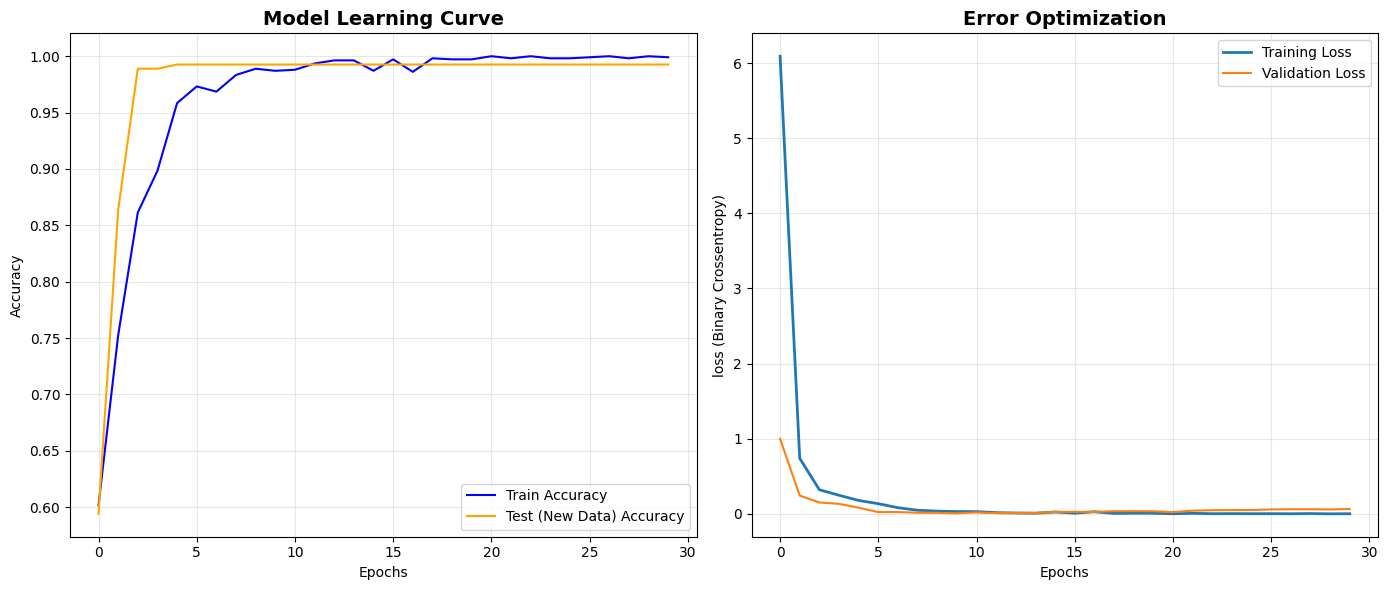


🏆 FINAL TEST ACCURACY: 99.26%


In [6]:
# 1. Train the Model
# We store the history so we can plot it later
print("🧠 Starting Training...")
history = model.fit(
    X_train, y_train, 
    epochs=30, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)

# 2. Visualize the Results
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Test (New Data) Accuracy', color='orange')
plt.title('Model Learning Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc ='lower right')
plt.grid(True, alpha =0.3)

# Plot Loss (Error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth = 2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e')
plt.title('Error Optimization', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('loss (Binary Crossentropy)')
plt.legend(loc = 'upper right')
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

# 3. Final Score
loss, accuracy = model.evaluate(X_test, y_test, verbose =0)
print(f"\n🏆 FINAL TEST ACCURACY: {accuracy*100:.2f}%")

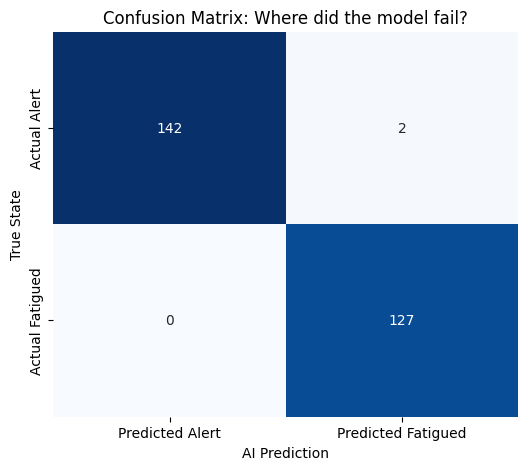


⚠️ FALSE NEGATIVES (Dangerous Errors): 0
⚠️ FALSE NEGATIVE RATE: 0.00%
✅ RECALL (Sensitivity): 100.00%

🏆 MISSION SUCCESS: The model caught EVERY fatigue event. Ready for Deployment.


In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Get Predictions
# The model outputs a probability (e.g., 0.99 or 0.01). We round it to get 0 or 1.
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Compute the Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot Professional Heatmap
plt.figure(figsize=(6, 5))
# [DS Skill Focus]: Visualizing Model Performance beyond simple Accuracy
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Alert', 'Predicted Fatigued'],
            yticklabels=['Actual Alert', 'Actual Fatigued'])
plt.title('Confusion Matrix: Where did the model fail?')
plt.ylabel('True State')
plt.xlabel('AI Prediction')
plt.show()

# 4. The Safety Check (The "Fatal Error" Calculation)
# TN = True Negative, FP = False Positive, FN = False Negative, TP = True Positive
tn, fp, fn, tp = cm.ravel()

false_negative_rate = fn / (fn + tp)
recall = tp / (tp + fn)

print(f"\n⚠️ FALSE NEGATIVES (Dangerous Errors): {fn}")
print(f"⚠️ FALSE NEGATIVE RATE: {false_negative_rate*100:.2f}%")
print(f"✅ RECALL (Sensitivity): {recall*100:.2f}%")

if fn == 0:
    print("\n🏆 MISSION SUCCESS: The model caught EVERY fatigue event. Ready for Deployment.")
else:
    print(f"\n⚠️ CAUTION: The model missed {fn} fatigue events. Threshold adjustment needed.")

🔍 Running Diagnostics on Test Set...


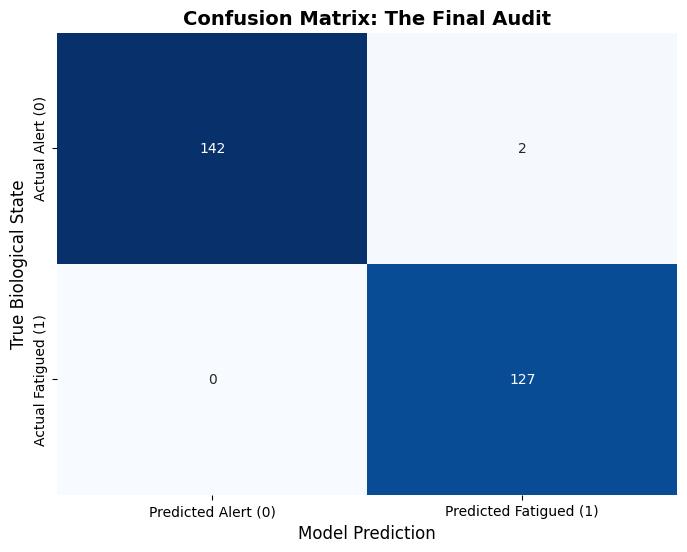


📝 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Alert       1.00      0.99      0.99       144
    Fatigued       0.98      1.00      0.99       127

    accuracy                           0.99       271
   macro avg       0.99      0.99      0.99       271
weighted avg       0.99      0.99      0.99       271


⚖️ TEST SET BALANCE: {0: 144, 1: 127}
If you see roughly equal numbers of 0s and 1s above, the 99% is REAL.


In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# [DS Skill Focus: Model Auditing] / [PhD Relevance: Error Type Analysis]

# 1. Get Predictions
print("🔍 Running Diagnostics on Test Set...")
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Generate the Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Visualizing the "Truth"
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Alert (0)', 'Predicted Fatigued (1)'],
            yticklabels=['Actual Alert (0)', 'Actual Fatigued (1)'])

plt.title('Confusion Matrix: The Final Audit', fontsize=14, fontweight='bold')
plt.xlabel('Model Prediction', fontsize=12)
plt.ylabel('True Biological State', fontsize=12)
plt.show()

# 4. The Report Card
print("\n📝 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Alert', 'Fatigued']))

# 5. Sanity Check on Test Data Distribution
unique, counts = np.unique(y_test, return_counts=True)
print(f"\n⚖️ TEST SET BALANCE: {dict(zip(unique, counts))}")
print("If you see roughly equal numbers of 0s and 1s above, the 99% is REAL.")

In [10]:
# [DS Skill Focus: Permutation Testing / Null Hypothesis Validation]
# We are going to intentionally break the data to see if the model breaks.

print("🧪 STARTING THE SANITY CHECK (Permutation Test)...")

# 1. Scramble the Training Labels
# We keep X (Brainwaves) the same, but we shuffle y (Labels) randomly.
# This means the model is trying to learn garbage patterns.
y_train_scrambled = np.random.permutation(y_train)

# 2. Build a fresh model (Same architecture)
sanity_model = Sequential([ 
    Conv1D(filters=16, kernel_size=10, activation='relu', input_shape=(1024, 4)),
    MaxPooling1D(pool_size=4),
    Conv1D(filters=32, kernel_size=10, activation='relu'),
    MaxPooling1D(pool_size=4),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

sanity_model.compile(optimizer=Adam(learning_rate=0.001), 
                     loss='binary_crossentropy', 
                     metrics=['accuracy'])

# 3. Train on Garbage Data
print("🧠 Training on Scrambled Labels (Expect ~50% Accuracy)...")
history_sanity = sanity_model.fit(
    X_train, y_train_scrambled,  # <--- Note the scrambled labels
    epochs=10,                   # 10 epochs is enough to see
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)

# 4. Final Verdict
loss, acc = sanity_model.evaluate(X_test, y_test, verbose=0)
print(f"\n📉 SANITY CHECK ACCURACY: {acc*100:.2f}%")

if acc < 0.60:
    print("✅ PASS: The model failed when given garbage data. ")
else:
    print("❌ FAIL: The model learned nothing but still guessed right. Something is wrong.")

🧪 STARTING THE SANITY CHECK (Permutation Test)...
🧠 Training on Scrambled Labels (Expect ~50% Accuracy)...
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4921 - loss: 24.2551 - val_accuracy: 0.4723 - val_loss: 2.5663
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5157 - loss: 1.2015 - val_accuracy: 0.4170 - val_loss: 0.7138
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5441 - loss: 0.7289 - val_accuracy: 0.5978 - val_loss: 0.6814
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5393 - loss: 0.6896 - val_accuracy: 0.4871 - val_loss: 0.7172
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5649 - loss: 0.6774 - val_accuracy: 0.4834 - val_loss: 0.6993
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5652 - loss: 0.6621 - val_accuracy: 0.4760 - val_loss: 0.6919
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5840 - loss: 0.6649 - val_accuracy: 0.4908 - val_loss: 0.7078
Epo